In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../data/raw/Steel_industry_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (35040, 11)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  str    
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  str    
 9   Day_of_week                           35040 non-null  str    
 10  Load_Type                             35040 non-null  str    
dtypes: float64(6), int64(1), s

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Number of rows: 35040
Number of columns: 11

Columns:
1. date
2. Usage_kWh
3. Lagging_Current_Reactive.Power_kVarh
4. Leading_Current_Reactive_Power_kVarh
5. CO2(tCO2)
6. Lagging_Current_Power_Factor
7. Leading_Current_Power_Factor
8. NSM
9. WeekStatus
10. Day_of_week
11. Load_Type


In [4]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing

,missing_count,missing_percent
date,0,0.0
Usage_kWh,0,0.0
Lagging_Current_Reactive.Power_kVarh,0,0.0
Leading_Current_Reactive_Power_kVarh,0,0.0
CO2(tCO2),0,0.0
Lagging_Current_Power_Factor,0,0.0
Leading_Current_Power_Factor,0,0.0
NSM,0,0.0
WeekStatus,0,0.0
Day_of_week,0,0.0


In [5]:
print("Duplicated rows:", df.duplicated().sum())

Duplicated rows: 0


In [6]:
categorical_cols = [
    "WeekStatus",
    "Day_of_week",
    "Load_Type"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- WeekStatus ---
WeekStatus
Weekday    25056
Weekend     9984
Name: count, dtype: int64

--- Day_of_week ---
Day_of_week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       4992
Name: count, dtype: int64

--- Load_Type ---
Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64


In [7]:
print("Current dtype:", df["date"].dtype)

print("\nFirst 10 values:")
print(df["date"].head(10))

print("\nLast 10 values:")
print(df["date"].tail(10))

Current dtype: str

First 10 values:
0    01/01/2018 00:15
1    01/01/2018 00:30
2    01/01/2018 00:45
3    01/01/2018 01:00
4    01/01/2018 01:15
5    01/01/2018 01:30
6    01/01/2018 01:45
7    01/01/2018 02:00
8    01/01/2018 02:15
9    01/01/2018 02:30
Name: date, dtype: str

Last 10 values:
35030    31/12/2018 21:45
35031    31/12/2018 22:00
35032    31/12/2018 22:15
35033    31/12/2018 22:30
35034    31/12/2018 22:45
35035    31/12/2018 23:00
35036    31/12/2018 23:15
35037    31/12/2018 23:30
35038    31/12/2018 23:45
35039    31/12/2018 00:00
Name: date, dtype: str


In [8]:
df["date"] = pd.to_datetime(
    df["date"],
    format="%d/%m/%Y %H:%M"
)

print("New dtype:", df["date"].dtype)
print("Start:", df["date"].min())
print("End:", df["date"].max())

New dtype: datetime64[us]
Start: 2018-01-01 00:00:00
End: 2018-12-31 23:45:00


In [9]:
print("Number of timestamps:", len(df))
print("Unique timestamps:", df["date"].nunique())
print("Duplicated timestamps:", df["date"].duplicated().sum())

print("\nTime range:")
print(df["date"].min(), "→", df["date"].max())

Number of timestamps: 35040
Unique timestamps: 35040
Duplicated timestamps: 0

Time range:
2018-01-01 00:00:00 → 2018-12-31 23:45:00


In [10]:
sorted_dates = df["date"].sort_values()

time_diff = sorted_dates.diff()

print("Most common time intervals:")
print(time_diff.value_counts().head())

print("\nNumber of intervals different from 15 minutes:")
print((time_diff.dropna() != pd.Timedelta(minutes=15)).sum())

Most common time intervals:
date
0 days 00:15:00    35039
Name: count, dtype: int64

Number of intervals different from 15 minutes:
0


In [11]:
df = df.sort_values("date").reset_index(drop=True)

In [12]:
df[["date", "Usage_kWh"]].head(10)

,date,Usage_kWh
0,2018-01-01 00:00:00,3.42
1,2018-01-01 00:15:00,3.17
2,2018-01-01 00:30:00,4.00
3,2018-01-01 00:45:00,3.24
4,2018-01-01 01:00:00,3.31
5,2018-01-01 01:15:00,3.82
6,2018-01-01 01:30:00,3.28
7,2018-01-01 01:45:00,3.60
8,2018-01-01 02:00:00,3.60
9,2018-01-01 02:15:00,3.28


In [13]:
df[["date", "Usage_kWh"]].tail(10)

,date,Usage_kWh
35030,2018-12-31 21:30:00,3.49
35031,2018-12-31 21:45:00,3.42
35032,2018-12-31 22:00:00,3.42
35033,2018-12-31 22:15:00,3.24
35034,2018-12-31 22:30:00,3.67
35035,2018-12-31 22:45:00,3.82
35036,2018-12-31 23:00:00,3.85
35037,2018-12-31 23:15:00,3.74
35038,2018-12-31 23:30:00,3.78
35039,2018-12-31 23:45:00,3.78


In [14]:
df["Usage_kWh"].describe()

count    35040.000000
mean        27.386892
std         33.444380
min          0.000000
25%          3.200000
50%          4.570000
75%         51.237500
max        157.180000
Name: Usage_kWh, dtype: float64

In [15]:
print("Negative values:", (df["Usage_kWh"] < 0).sum())
print("Zero values:", (df["Usage_kWh"] == 0).sum())
print("Minimum:", df["Usage_kWh"].min())
print("Maximum:", df["Usage_kWh"].max())

Negative values: 0
Zero values: 1
Minimum: 0.0
Maximum: 157.18


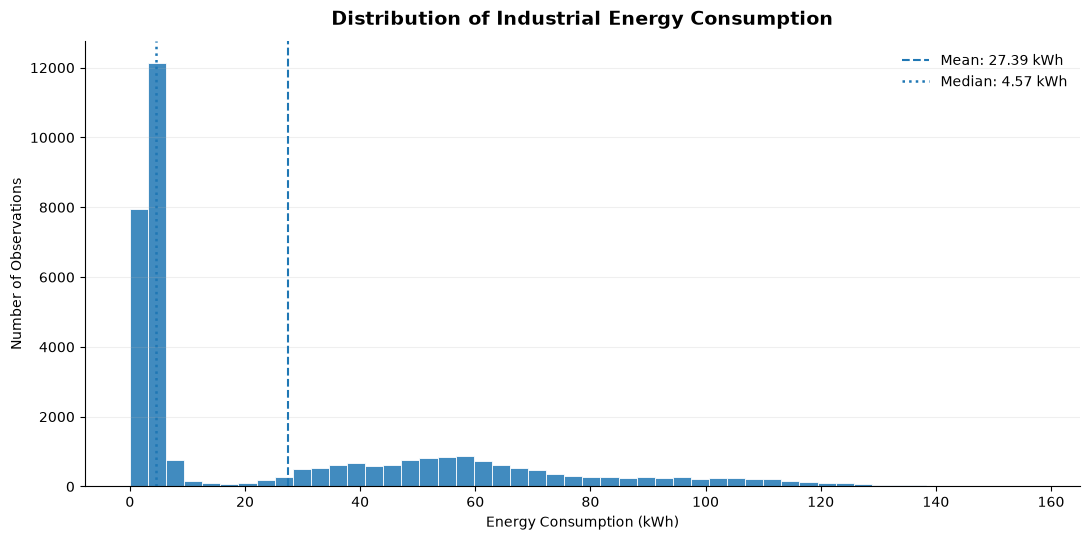

In [16]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.hist(
    df["Usage_kWh"],
    bins=50,
    edgecolor="white",
    linewidth=0.7,
    alpha=0.85
)

# Mean & Median
mean_usage = df["Usage_kWh"].mean()
median_usage = df["Usage_kWh"].median()

ax.axvline(
    mean_usage,
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_usage:.2f} kWh"
)

ax.axvline(
    median_usage,
    linestyle=":",
    linewidth=1.8,
    label=f"Median: {median_usage:.2f} kWh"
)

ax.set_title(
    "Distribution of Industrial Energy Consumption",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Energy Consumption (kWh)")
ax.set_ylabel("Number of Observations")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

C:\Users\kurok\AppData\Local\Temp\ipykernel_31680\914289580.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(


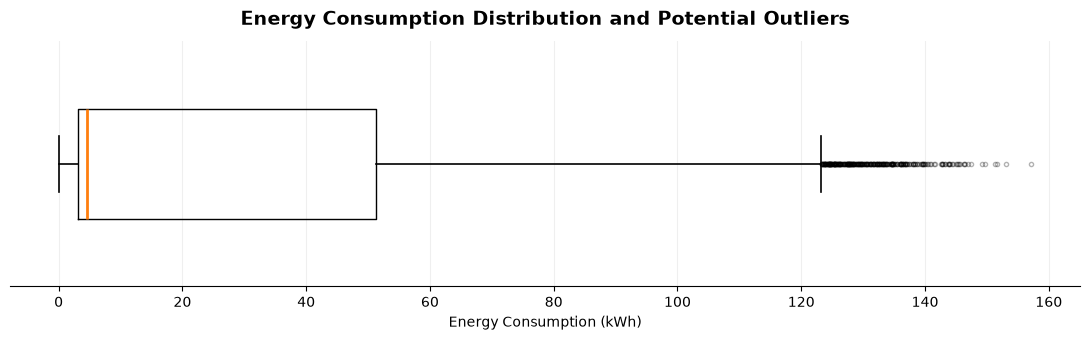

In [17]:
fig, ax = plt.subplots(figsize=(11, 3.5))

ax.boxplot(
    df["Usage_kWh"],
    vert=False,
    widths=0.45,
    patch_artist=False,
    medianprops={"linewidth": 2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    flierprops={
        "marker": "o",
        "markersize": 3,
        "alpha": 0.3
    }
)

ax.set_title(
    "Energy Consumption Distribution and Potential Outliers",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Energy Consumption (kWh)")
ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.show()

In [18]:
summary = pd.DataFrame({
    "Metric": [
        "Observations",
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Q1 (25%)",
        "Q3 (75%)",
        "Maximum",
        "Zero Values",
        "Negative Values"
    ],
    "Value": [
        len(df),
        df["Usage_kWh"].mean(),
        df["Usage_kWh"].median(),
        df["Usage_kWh"].std(),
        df["Usage_kWh"].min(),
        df["Usage_kWh"].quantile(0.25),
        df["Usage_kWh"].quantile(0.75),
        df["Usage_kWh"].max(),
        (df["Usage_kWh"] == 0).sum(),
        (df["Usage_kWh"] < 0).sum()
    ]
})

summary

,Metric,Value
0,Observations,35040.000000
1,Mean,27.386892
2,Median,4.570000
3,Standard Deviation,33.444380
4,Minimum,0.000000
5,Q1 (25%),3.200000
6,Q3 (75%),51.237500
7,Maximum,157.180000
8,Zero Values,1.000000
9,Negative Values,0.000000


In [19]:
zero_usage = df[df["Usage_kWh"] == 0]

zero_usage.T

,29760
date,2018-11-07 00:00:00
Usage_kWh,0.0
Lagging_Current_Reactive.Power_kVarh,0.0
Leading_Current_Reactive_Power_kVarh,0.0
CO2(tCO2),0.0
Lagging_Current_Power_Factor,0.0
Leading_Current_Power_Factor,0.0
NSM,0
WeekStatus,Weekday
Day_of_week,Wednesday


In [20]:
load_summary = (
    df.groupby("Load_Type")["Usage_kWh"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

load_summary

,count,mean,median,std,min,max
Load_Type,,,,,,
Light_Load,18072,8.63,3.31,17.91,0.00,140.29
Maximum_Load,7272,59.27,56.63,29.75,2.92,151.67
Medium_Load,9696,38.45,34.44,35.22,2.52,157.18


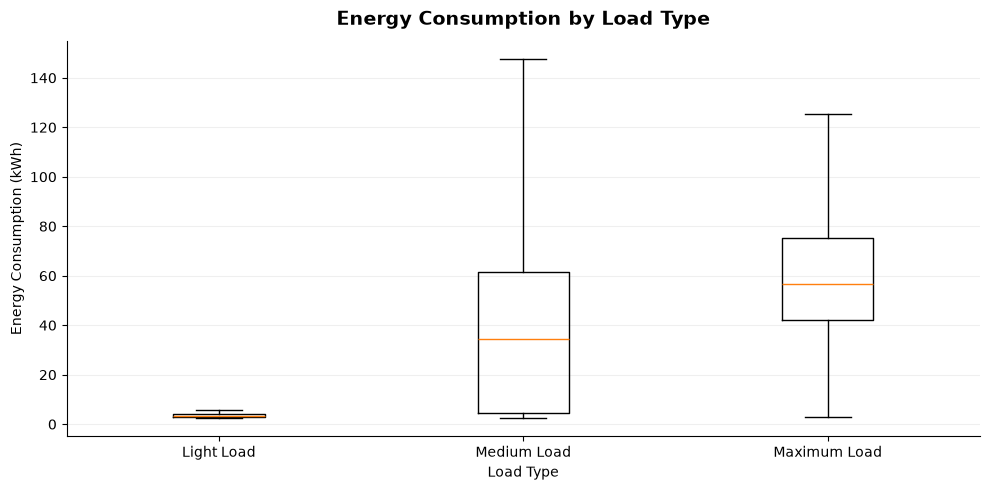

In [21]:
load_order = ["Light_Load", "Medium_Load", "Maximum_Load"]

data_by_load = [
    df.loc[df["Load_Type"] == load, "Usage_kWh"]
    for load in load_order
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(
    data_by_load,
    tick_labels=["Light Load", "Medium Load", "Maximum Load"],
    showfliers=False
)

ax.set_title(
    "Energy Consumption by Load Type",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Load Type")
ax.set_ylabel("Energy Consumption (kWh)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

In [22]:
high_usage = (
    df[df["Usage_kWh"] >= 120]
    [["date", "Usage_kWh", "Load_Type", "WeekStatus", "Day_of_week"]]
    .sort_values("Usage_kWh", ascending=False)
)

print("Number of observations >= 120 kWh:", len(high_usage))

print("\nBy Load Type:")
print(high_usage["Load_Type"].value_counts())

high_usage.head(20)

Number of observations >= 120 kWh: 447

By Load Type:
Load_Type
Medium_Load     205
Maximum_Load    200
Light_Load       42
Name: count, dtype: int64


,date,Usage_kWh,Load_Type,WeekStatus,Day_of_week
31239,2018-11-22 09:45:00,157.18,Medium_Load,Weekday,Thursday
1399,2018-01-15 13:45:00,153.14,Medium_Load,Weekday,Monday
31724,2018-11-27 11:00:00,151.67,Maximum_Load,Weekday,Tuesday
7813,2018-03-23 09:15:00,151.31,Medium_Load,Weekday,Friday
1702,2018-01-18 17:30:00,149.65,Maximum_Load,Weekday,Thursday
33849,2018-12-19 14:15:00,149.18,Medium_Load,Weekday,Wednesday
163,2018-01-02 16:45:00,147.46,Medium_Load,Weekday,Tuesday
6112,2018-03-05 16:00:00,146.88,Maximum_Load,Weekday,Monday
1680,2018-01-18 12:00:00,146.48,Maximum_Load,Weekday,Thursday
448,2018-01-05 16:00:00,146.34,Medium_Load,Weekday,Friday


In [23]:
df["hour"] = df["date"].dt.hour + df["date"].dt.minute / 60

hourly_usage = (
    df.groupby("hour")["Usage_kWh"]
      .agg(["mean", "median"])
      .reset_index()
)

hourly_usage.head()

,hour,mean,median
0,0.00,7.977205,3.53
1,0.25,7.683589,3.46
2,0.50,8.091534,3.49
3,0.75,7.727973,3.42
4,1.00,7.804356,3.42


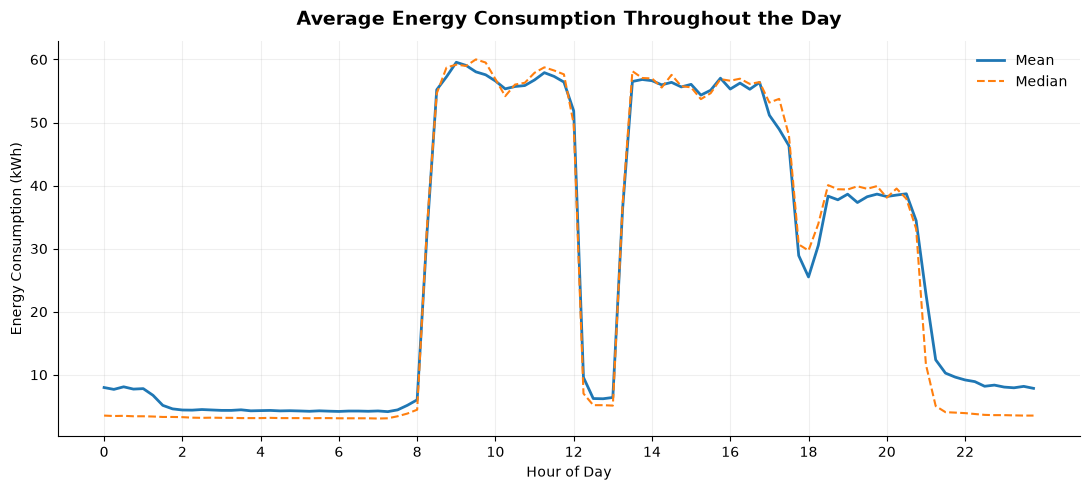

In [24]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    hourly_usage["hour"],
    hourly_usage["mean"],
    linewidth=2,
    label="Mean"
)

ax.plot(
    hourly_usage["hour"],
    hourly_usage["median"],
    linewidth=1.5,
    linestyle="--",
    label="Median"
)

ax.set_title(
    "Average Energy Consumption Throughout the Day",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Energy Consumption (kWh)")

ax.set_xticks(range(0, 24, 2))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [25]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_usage = (
    df.groupby("Day_of_week")["Usage_kWh"]
      .agg(["mean", "median"])
      .reindex(day_order)
)

daily_usage.round(2)

,mean,median
Day_of_week,,
Monday,33.14,6.28
Tuesday,34.43,9.29
Wednesday,32.25,5.85
Thursday,35.11,19.85
Friday,33.20,9.02
Saturday,15.92,3.74
Sunday,7.55,3.20


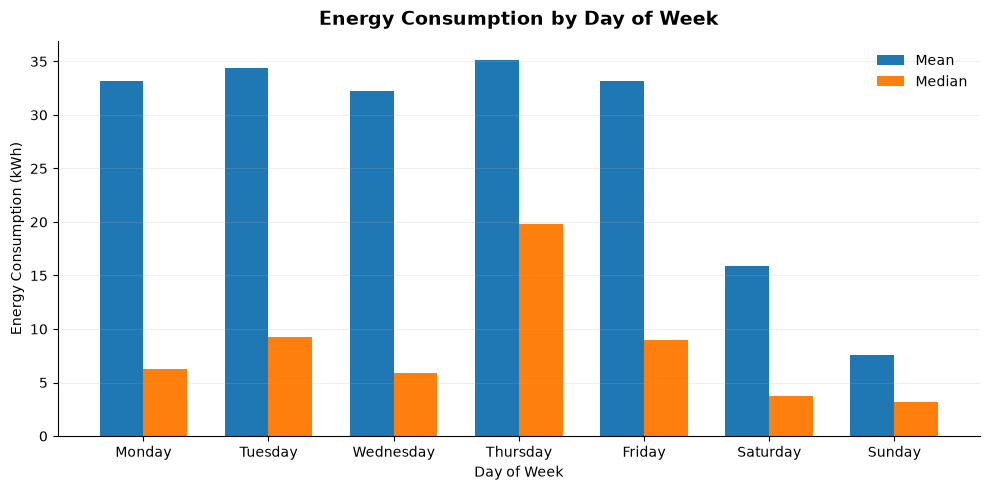

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(day_order))
width = 0.35

ax.bar(
    x - width / 2,
    daily_usage["mean"],
    width,
    label="Mean"
)

ax.bar(
    x + width / 2,
    daily_usage["median"],
    width,
    label="Median"
)

ax.set_title(
    "Energy Consumption by Day of Week",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Energy Consumption (kWh)")

ax.set_xticks(x)
ax.set_xticklabels(day_order)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [27]:
week_summary = (
    df.groupby("WeekStatus")["Usage_kWh"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(2)
)

week_summary

,count,mean,median,std,min,max
WeekStatus,,,,,,
Weekday,25056,33.62,7.60,35.62,0.00,157.18
Weekend,9984,11.73,3.46,19.95,2.45,133.42


In [28]:
df["month"] = df["date"].dt.month

monthly_usage = (
    df.groupby("month")["Usage_kWh"]
      .agg(["mean", "median"])
      .reset_index()
)

monthly_usage.round(2)

,month,mean,median
0,1,42.42,33.37
1,2,34.04,6.43
2,3,26.96,4.93
3,4,27.35,4.14
4,5,26.57,3.74
5,6,22.71,3.64
6,7,27.44,3.85
7,8,23.04,3.24
8,9,20.10,3.28
9,10,28.45,4.07


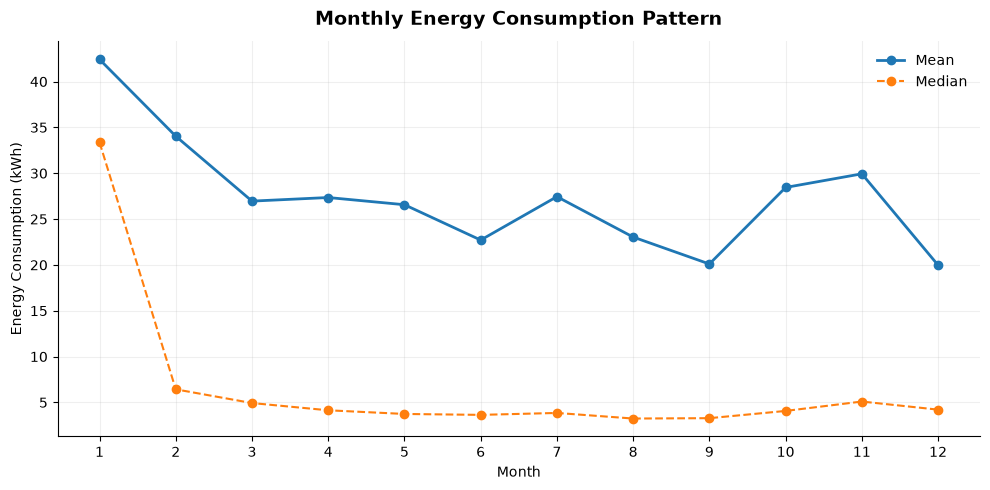

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    monthly_usage["month"],
    monthly_usage["mean"],
    marker="o",
    linewidth=2,
    label="Mean"
)

ax.plot(
    monthly_usage["month"],
    monthly_usage["median"],
    marker="o",
    linestyle="--",
    linewidth=1.5,
    label="Median"
)

ax.set_title(
    "Monthly Energy Consumption Pattern",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Month")
ax.set_ylabel("Energy Consumption (kWh)")

ax.set_xticks(range(1, 13))

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(alpha=0.2)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [30]:
numeric_cols = [
    "Usage_kWh",
    "Lagging_Current_Reactive.Power_kVarh",
    "Leading_Current_Reactive_Power_kVarh",
    "CO2(tCO2)",
    "Lagging_Current_Power_Factor",
    "Leading_Current_Power_Factor",
    "NSM"
]

correlation_matrix = df[numeric_cols].corr()

target_corr = (
    correlation_matrix["Usage_kWh"]
    .sort_values(ascending=False)
)

target_corr

Usage_kWh                               1.000000
CO2(tCO2)                               0.988180
Lagging_Current_Reactive.Power_kVarh    0.896150
Lagging_Current_Power_Factor            0.385960
Leading_Current_Power_Factor            0.353566
NSM                                     0.234610
Leading_Current_Reactive_Power_kVarh   -0.324922
Name: Usage_kWh, dtype: float64

In [31]:
df[[
    "Usage_kWh",
    "CO2(tCO2)"
]].head(20)

,Usage_kWh,CO2(tCO2)
0,3.42,0.0
1,3.17,0.0
2,4.00,0.0
3,3.24,0.0
4,3.31,0.0
5,3.82,0.0
6,3.28,0.0
7,3.60,0.0
8,3.60,0.0
9,3.28,0.0


In [32]:
nonzero_co2 = df[df["CO2(tCO2)"] > 0].copy()

nonzero_co2["usage_co2_ratio"] = (
    nonzero_co2["Usage_kWh"] /
    nonzero_co2["CO2(tCO2)"]
)

nonzero_co2["usage_co2_ratio"].describe()

count    14050.000000
mean      2211.775909
std        330.647425
min       1091.000000
25%       1992.000000
50%       2168.800000
75%       2391.250000
max       3269.000000
Name: usage_co2_ratio, dtype: float64

In [33]:
lags = {
    "15 min": 1,
    "30 min": 2,
    "1 hour": 4,
    "2 hours": 8,
    "6 hours": 24,
    "12 hours": 48,
    "24 hours": 96,
    "7 days": 672
}

lag_correlations = {}

for name, lag in lags.items():
    lag_correlations[name] = df["Usage_kWh"].corr(
        df["Usage_kWh"].shift(lag)
    )

lag_corr_df = pd.DataFrame(
    lag_correlations.items(),
    columns=["Lag", "Correlation"]
)

lag_corr_df

,Lag,Correlation
0,15 min,0.911546
1,30 min,0.834341
2,1 hour,0.686786
3,2 hours,0.539777
4,6 hours,0.227048
5,12 hours,-0.242817
6,24 hours,0.606296
7,7 days,0.676703


In [34]:
df[["date", "NSM"]].head(10)

,date,NSM
0,2018-01-01 00:00:00,0
1,2018-01-01 00:15:00,900
2,2018-01-01 00:30:00,1800
3,2018-01-01 00:45:00,2700
4,2018-01-01 01:00:00,3600
5,2018-01-01 01:15:00,4500
6,2018-01-01 01:30:00,5400
7,2018-01-01 01:45:00,6300
8,2018-01-01 02:00:00,7200
9,2018-01-01 02:15:00,8100


In [35]:
print("NSM min:", df["NSM"].min())
print("NSM max:", df["NSM"].max())
print("NSM unique:", df["NSM"].nunique())

NSM min: 0
NSM max: 85500
NSM unique: 96
